In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [4]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [5]:
graph = StateGraph(QuadState)

In [6]:
def show_equation(state:QuadState) -> str:
    equation = f"{state['a']}*x2 + {state['b']}*x + {state['c']}"
   
    return {'equation':equation}

def calculate_discriminant(state: QuadState) -> int:
    discriminant = (state['b']**2) - (4 * state['a'] * state['c'])
    return {'discriminant':discriminant}

def calculate_real_roots(state: QuadState) -> dict:
    root1 = (-state['b'] + state['discriminant'] ** 0.5) / (2 * state['a'])
    root2 = (-state['b'] - state['discriminant'] ** 0.5) / (2 * state['a'])

    result = f"The roots are {root1} and {root2}"

    return {'result': result}

def calculate_repeated_roots(state: QuadState) -> dict:
    root = -state['b'] / (2 * state['a'])

    result = f"The repeated root is {root}"

    return {'result': result}

def no_real_roots(state: QuadState) -> dict:
    result = "No real roots"

    return {'result': result}

def check_condition(state: QuadState) -> Literal['calculate_real_roots', 'calculate_repeated_roots', 'no_real_roots']:
    discriminant = state['discriminant']

    if discriminant > 0:
        return 'calculate_real_roots'
    elif discriminant == 0:
        return 'calculate_repeated_roots'
    else:
        return 'no_real_roots'


In [7]:
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('calculate_real_roots', calculate_real_roots)
graph.add_node('calculate_repeated_roots', calculate_repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

In [8]:
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('calculate_real_roots', END)
graph.add_edge('calculate_repeated_roots', END)
graph.add_edge('no_real_roots', END)


In [9]:
workflow = graph.compile()

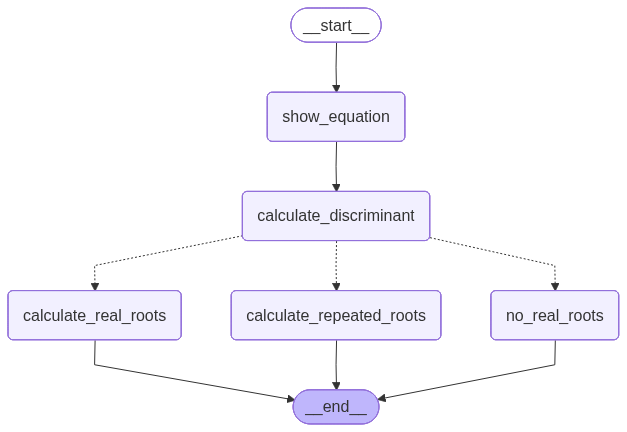

In [10]:
workflow

In [11]:
initial_state = {
    'a':1,
    'b':2,
    'c':1
}

In [12]:
workflow.invoke(initial_state)

{'a': 1,
 'b': 2,
 'c': 1,
 'equation': '1*x2 + 2*x + 1',
 'discriminant': 0,
 'result': 'The repeated root is -1.0'}